<a href="https://colab.research.google.com/github/AchyuthaAshish/AI-ML-Projects/blob/main/03_Employee_Attrition_Prediction/Employee_Attrition_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Attrition Prediction Using Random Forest

**Objective:** Predict whether an employee is likely to stay or leave using the IBM HR Analytics Employee Attrition dataset.

**Workflow:** HR Data → Preprocessing → Feature Selection → Random Forest → Evaluation → New Employee Prediction.

> This is a learning project using a public, fictional HR dataset. Predictions are model estimates, not facts about an individual employee.

In [1]:
!pip -q install pandas numpy scikit-learn matplotlib seaborn joblib

In [2]:
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Download the dataset, trying two public mirrors if needed
file_name = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
dataset_urls = [
    "https://gist.githubusercontent.com/mmphego/67a4f2acb93f6d571eb18c430d5654e9/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv",
    "https://raw.githubusercontent.com/mragpavank/ibm-hr-analytics-attrition-dataset/master/WA_Fn-UseC_-HR-Employee-Attrition.csv",
]

if not os.path.exists(file_name):
    last_error = None
    for url in dataset_urls:
        try:
            urllib.request.urlretrieve(url, file_name)
            # Confirm the downloaded file is a readable CSV
            pd.read_csv(file_name, nrows=5)
            print(f"Dataset downloaded successfully from: {url}")
            break
        except Exception as exc:
            last_error = exc
            if os.path.exists(file_name):
                os.remove(file_name)
    else:
        raise RuntimeError(
            "Could not download the dataset. Upload "
            f"{file_name} manually to Colab. Last error: {last_error}"
        )
else:
    print("Dataset file already exists in this Colab session.")

Dataset downloaded successfully from: https://gist.githubusercontent.com/mmphego/67a4f2acb93f6d571eb18c430d5654e9/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv


In [4]:
df = pd.read_csv(file_name)

print("Dataset shape:", df.shape)
print("\nFirst five rows:")
display(df.head())

assert "Attrition" in df.columns, "The dataset must contain an Attrition column."
assert set(df["Attrition"].dropna().unique()).issubset({"Yes", "No"}), "Unexpected Attrition labels."

Dataset shape: (1470, 35)

First five rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
print("Target distribution:")
display(df["Attrition"].value_counts().rename_axis("Attrition").to_frame("Count"))

print("\nMissing values:", int(df.isnull().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

Target distribution:


,Count
Attrition,
No,1233
Yes,237



Missing values: 0
Duplicate rows: 0


In [6]:
# Remove identifiers and constant columns that are not useful predictors
columns_to_drop = ["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"]
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Remove exact duplicate rows if any exist
df = df.drop_duplicates().reset_index(drop=True)

# Save category levels before encoding so new inputs can be encoded consistently
target_column = "Attrition"
categorical_columns = df.drop(columns=[target_column]).select_dtypes(
    include=["object"]
).columns.tolist()
category_levels = {
    col: sorted(df[col].dropna().unique().tolist())
    for col in categorical_columns
}

print("Removed columns:", columns_to_drop)
print("Categorical columns:", categorical_columns)
print("Prepared dataset shape:", df.shape)

Removed columns: ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
Categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Prepared dataset shape: (1470, 31)


In [7]:
# Encode target: No = 0 (Stay), Yes = 1 (Leave)
y = df[target_column].map({"No": 0, "Yes": 1}).astype(int)

# Encode categorical input features
X_raw = df.drop(columns=[target_column]).copy()
X = pd.get_dummies(
    X_raw,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("Encoded feature matrix shape:", X.shape)
print("Target distribution (0=Stay, 1=Leave):")
display(y.value_counts().sort_index().rename(index={0: "Stay", 1: "Leave"}).to_frame("Count"))

Encoded feature matrix shape: (1470, 44)
Target distribution (0=Stay, 1=Leave):


,Count
Attrition,
Stay,1233
Leave,237


In [8]:
# Split before feature selection to avoid fitting the selector on test data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

Training rows: 1176
Testing rows : 294


In [9]:
# Select the 15 highest-scoring features using Chi-Square
k_features = min(15, X_train.shape[1])
selector = SelectKBest(score_func=chi2, k=k_features)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

selected_features = X.columns[selector.get_support()].tolist()

print(f"Selected {len(selected_features)} features:")
for feature in selected_features:
    print("-", feature)

Selected 15 features:
- Age
- DailyRate
- DistanceFromHome
- JobLevel
- MonthlyIncome
- MonthlyRate
- StockOptionLevel
- TotalWorkingYears
- YearsAtCompany
- YearsInCurrentRole
- YearsWithCurrManager
- JobRole_Laboratory Technician
- JobRole_Sales Representative
- MaritalStatus_Single
- OverTime_Yes


In [10]:
# Train the final Random Forest
model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight={0: 1, 1: 3},
    max_depth=12,
    min_samples_leaf=2,
    n_jobs=-1
)

model.fit(X_train_selected, y_train)
print("Improved Random Forest trained successfully.")

Improved Random Forest trained successfully.


In [11]:
# Final evaluation on the held-out test set
y_pred = model.predict(X_test_selected)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("=" * 58)
print("FINAL MODEL PERFORMANCE")
print("=" * 58)
print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1-score : {f1 * 100:.2f}%")

print("\nClassification report:")
print(classification_report(
    y_test, y_pred,
    labels=[0, 1],
    target_names=["Stay", "Leave"],
    zero_division=0
))

FINAL MODEL PERFORMANCE
Accuracy : 83.33%
Precision: 46.15%
Recall   : 25.53%
F1-score : 32.88%

Classification report:
              precision    recall  f1-score   support

        Stay       0.87      0.94      0.90       247
       Leave       0.46      0.26      0.33        47

    accuracy                           0.83       294
   macro avg       0.67      0.60      0.62       294
weighted avg       0.80      0.83      0.81       294



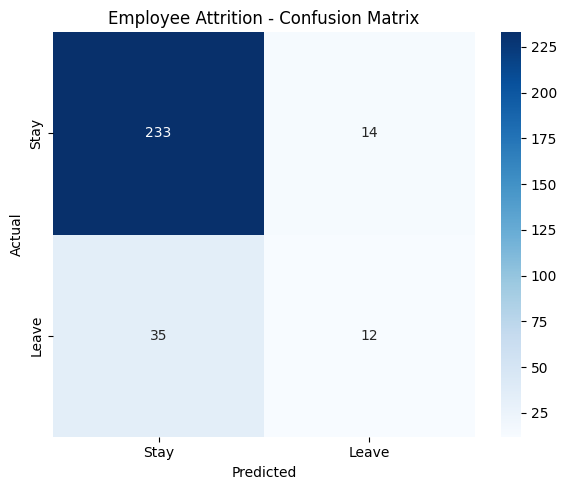

In [12]:
# Confusion matrix: rows are actual labels, columns are predicted labels
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stay", "Leave"],
    yticklabels=["Stay", "Leave"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Employee Attrition - Confusion Matrix")
plt.tight_layout()
plt.show()

,Feature,Importance
4,MonthlyIncome,0.131726
0,Age,0.108899
1,DailyRate,0.102155
5,MonthlyRate,0.090851
7,TotalWorkingYears,0.086553
2,DistanceFromHome,0.081156
8,YearsAtCompany,0.080392
14,OverTime_Yes,0.068467
10,YearsWithCurrManager,0.065427
6,StockOptionLevel,0.050718


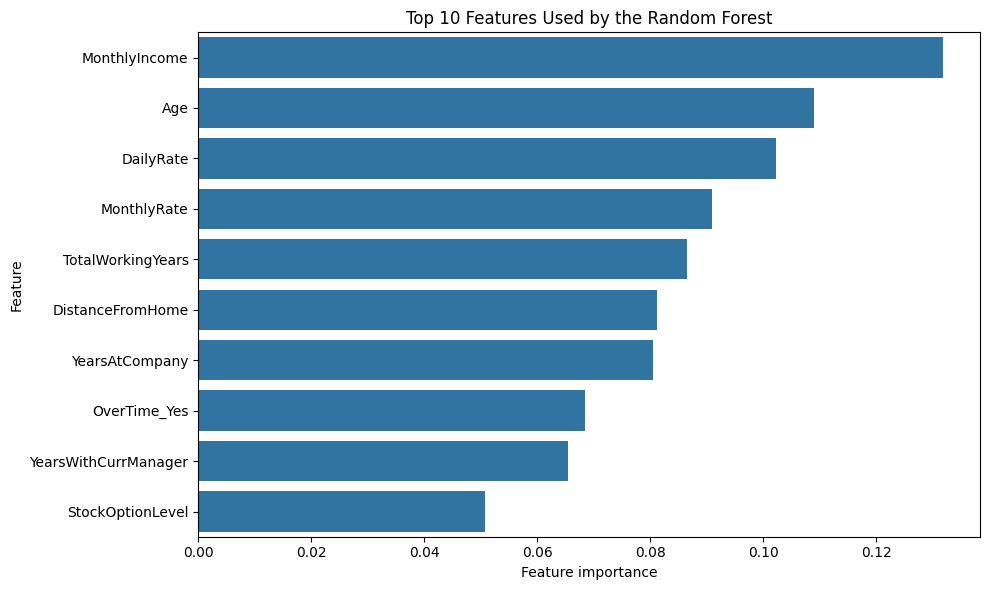

In [13]:
# Top 10 feature importances among the selected features
feature_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Features Used by the Random Forest")
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [14]:
def predict_attrition(employee):
    """Predict Stay/Leave for one employee dictionary using the trained model."""
    sample_df = pd.DataFrame([employee])

    expected_raw_columns = X_raw.columns.tolist()
    missing = [col for col in expected_raw_columns if col not in sample_df.columns]
    extra = [col for col in sample_df.columns if col not in expected_raw_columns]

    if missing:
        raise ValueError(f"Missing employee fields: {missing}")
    if extra:
        raise ValueError(f"Unexpected employee fields: {extra}")

    # Validate and apply the same category levels used during training
    for col in categorical_columns:
        value = sample_df.at[0, col]
        if value not in category_levels[col]:
            raise ValueError(
                f"Invalid value {value!r} for {col}. "
                f"Allowed values: {category_levels[col]}"
            )
        sample_df[col] = pd.Categorical(
            sample_df[col],
            categories=category_levels[col]
        )

    sample_encoded = pd.get_dummies(
        sample_df,
        columns=categorical_columns,
        drop_first=True,
        dtype=int
    )
    sample_encoded = sample_encoded.reindex(columns=X.columns, fill_value=0)

    sample_selected = selector.transform(sample_encoded)
    prediction = int(model.predict(sample_selected)[0])
    probabilities = model.predict_proba(sample_selected)[0]

    label = "Leave" if prediction == 1 else "Stay"
    # Return probabilities explicitly by class label, not assumed array position
    class_probability = dict(zip(model.classes_, probabilities))
    stay_probability = float(class_probability.get(0, 0.0))
    leave_probability = float(class_probability.get(1, 0.0))

    return label, stay_probability, leave_probability

In [15]:
# Example new employee input. Include every feature used by the dataset.
sample_employee = {
    "Age": 28,
    "BusinessTravel": "Travel_Rarely",
    "DailyRate": 800,
    "Department": "Sales",
    "DistanceFromHome": 10,
    "Education": 3,
    "EducationField": "Marketing",
    "EnvironmentSatisfaction": 2,
    "Gender": "Male",
    "HourlyRate": 65,
    "JobInvolvement": 3,
    "JobLevel": 1,
    "JobRole": "Sales Executive",
    "JobSatisfaction": 2,
    "MaritalStatus": "Single",
    "MonthlyIncome": 3000,
    "MonthlyRate": 18000,
    "NumCompaniesWorked": 1,
    "OverTime": "Yes",
    "PercentSalaryHike": 12,
    "PerformanceRating": 3,
    "RelationshipSatisfaction": 2,
    "StockOptionLevel": 0,
    "TotalWorkingYears": 5,
    "TrainingTimesLastYear": 2,
    "WorkLifeBalance": 2,
    "YearsAtCompany": 1,
    "YearsInCurrentRole": 0,
    "YearsSinceLastPromotion": 0,
    "YearsWithCurrManager": 0
}

prediction, stay_prob, leave_prob = predict_attrition(sample_employee)

print("=" * 58)
print("EMPLOYEE ATTRITION PREDICTION")
print("=" * 58)
print("Prediction:", prediction)
print(f"Estimated Stay probability : {stay_prob * 100:.2f}%")
print(f"Estimated Leave probability: {leave_prob * 100:.2f}%")

EMPLOYEE ATTRITION PREDICTION
Prediction: Leave
Estimated Stay probability : 23.02%
Estimated Leave probability: 76.98%


In [16]:
# Second example with a different employee profile
employee_2 = {
    "Age": 25,
    "BusinessTravel": "Travel_Frequently",
    "DailyRate": 300,
    "Department": "Sales",
    "DistanceFromHome": 25,
    "Education": 2,
    "EducationField": "Marketing",
    "EnvironmentSatisfaction": 1,
    "Gender": "Male",
    "HourlyRate": 45,
    "JobInvolvement": 1,
    "JobLevel": 1,
    "JobRole": "Sales Executive",
    "JobSatisfaction": 1,
    "MaritalStatus": "Single",
    "MonthlyIncome": 2500,
    "MonthlyRate": 12000,
    "NumCompaniesWorked": 4,
    "OverTime": "Yes",
    "PercentSalaryHike": 11,
    "PerformanceRating": 3,
    "RelationshipSatisfaction": 1,
    "StockOptionLevel": 0,
    "TotalWorkingYears": 2,
    "TrainingTimesLastYear": 1,
    "WorkLifeBalance": 1,
    "YearsAtCompany": 1,
    "YearsInCurrentRole": 0,
    "YearsSinceLastPromotion": 0,
    "YearsWithCurrManager": 0
}

prediction_2, stay_prob_2, leave_prob_2 = predict_attrition(employee_2)
print("Test 2 prediction:", prediction_2)
print(f"Estimated Stay probability : {stay_prob_2 * 100:.2f}%")
print(f"Estimated Leave probability: {leave_prob_2 * 100:.2f}%")

Test 2 prediction: Leave
Estimated Stay probability : 16.62%
Estimated Leave probability: 83.38%


In [17]:
# Save the final model artifacts for optional later use
joblib.dump(model, "employee_attrition_random_forest.pkl")
joblib.dump(selector, "employee_attrition_feature_selector.pkl")
joblib.dump(X.columns.tolist(), "employee_attrition_features.pkl")
joblib.dump(category_levels, "employee_attrition_category_levels.pkl")

print("Final model, feature selector, feature names, and category levels saved.")

Final model, feature selector, feature names, and category levels saved.
